A parametric model of circumstellar disks 
---
See e.g. section 3.1 in https://ui.adsabs.harvard.edu/abs/2014ApJ...788...59W/abstract

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import os, sys
import matplotlib
from pathlib import Path
from ruamel.yaml import YAML
from tqdm.auto import tqdm
import astropy
from disksurf import observation
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk
from network import shard
from consts import *

data_dir = Path('../../data/alma/')

In [11]:
data_cube = observation('../../data/alma/HD163296_CO_highres_cen.cm.fits')

In [2]:
def render_cube(projection, disk, freqs, numberdens_co_sph, temperature_sph, bbox):
    pixel_area = (projection.fov/projection.npix)**2       # pixel area to convert radiances to Jy 
    ray_coords, obs_dir = sensor.orthographic_disk_projection(projection.npix, projection.nray, projection.incl, projection.phi, projection.posang, 
                                                              projection.fov, projection.r_min, projection.r_max, projection.theta_min, projection.theta_max)
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords, logr=True)
    
    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(numberdens_co_sph, ray_coords_sph, bbox)
    gas_t  = grid.interpolate_scalar(temperature_sph, ray_coords_sph, bbox, cval=1e-10)
    gas_v = parametric_disk.keplerian_velocity(ray_coords, disk.M_star)
    
    # Einstein coefficient for spontaneous emission from level u to level d
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions)
    n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions)
    print('line frequency: {} Ghz'.format(projection.nu0/ghz))

    # Define a parallel mapping over several gpus
    pmap = jax.pmap(line_rte.compute_spectral_cube,
                    axis_name='freq', 
                    in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None))

    print('computing spectral cube for a total of {} frequencies'.format(freqs.size))
    images = pmap(shard(freqs), gas_v, gas_t, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, projection.nu0, pixel_area, disk.alpha_turb)
    images = np.nan_to_num(images).reshape(projection.linelam, projection.npix, projection.npix)
    return images

Define a parametric ground truth model and render line radiative transfer cubes
--

In [3]:
disk = parametric_disk.DiskFlaherty(
    name='MWC480_Fiducial',
    alpha_turb=0.114,
    T_mid1=18.8,
    T_atm1=60.3,
    q=0.467,
    M_star=1.85*M_sun,
    gamma=1.0,
    r_in=9.0,
    r_c=10**2.161,
    M_gas=0.046*M_sun,
    m_mol=2.37*m_h,
    co_abundance=1e-4,
    N_h2_min=1.3e21,
    N_h2_max=4.8e21,
    freezeout=20.0,
    r_scale=150.0,
    z_q0=50.0,
    molecule_table=os.path.join(data_dir, 'molecule_12c16o.inp')
)


distance = 161.1*pc          # distance
fov_rad =  10.0*arcsec       # field of view (RA/Dec) 
fov = 2 * distance * np.tan(fov_rad/2.0)  # 1611 [au]
projection = sensor.Projection(
    name='MWC480_Fiducial',
    npix=384,
    nray=100,
    incl=-40.34,
    phi=0.0,
    posang=-147.8,
    fov=fov,
    r_min=100*au,
    r_max=1000.0*au,
    theta_min=float(np.deg2rad(68.5)),
    theta_max=float(np.deg2rad(111.5)),
    linelam=9,
    width_kms=3.8,
    nu0=345795989900.0,
    v_sys=5.102,
)

params = {
    'desc': 'parametric circumstellar model based on: \
             https://arxiv.org/abs/2004.12176 fiducial parameters \
             The disk is defined as "DiskFlaherty"',
    'disk': disk.__dict__, 
    'projection': projection.__dict__
}

In [4]:
# Compute line radiative transfer for a whole spectral cube
freqs = sensor.compute_camera_freqs(projection.linelam, projection.width_kms, projection.nu0)[::-1]

z_min, z_max = 0, 200
r_min, r_max = disk.r_in, 800
numberdens_co, temperature = parametric_disk.density_temperature_profiles(disk, z_min, z_max, r_min, r_max, resolution=500)

# Make a spherical coordinate dataset with logarithmic spacing in r
phi, theta, r = np.meshgrid(np.linspace(0, 2*np.pi, 180), 
                            np.linspace(projection.theta_min, projection.theta_max, 120), 
                            au*np.logspace(np.log10(r_min), np.log10(r_max), 100), indexing='ij')
coords_sph = jnp.stack([phi, theta, r], axis=-1)

# Bounding box for interpolations (logarithmic r scale)
bbox_cyl = [(z_min*au, z_max*au), (r_min*au, r_max*au)]
bbox = [(phi.min(), phi.max()), (theta.min(), theta.max()), (np.log10(r.min()), np.log10(r.max()))]

# Polar coordinates with mirror and axial symmetry
r_polar = r * np.sin(theta)
z = np.abs(r * np.cos(theta))
coords_polar = np.stack((z, r), axis=-1)

# Interpolate the data on spherical coordinates
numberdens_co_sph = grid.interpolate_scalar(numberdens_co, coords_polar, bbox=bbox_cyl)
temperature_sph = grid.interpolate_scalar(temperature, coords_polar, bbox=bbox_cyl)
images = render_cube(projection, disk, freqs, numberdens_co_sph, temperature_sph, bbox)

2024-05-09 09:14:47.737643: W external/xla/xla/service/gpu/nvptx_compiler.cc:698] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.4.131). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


line frequency: 345.7959899 Ghz
computing spectral cube for a total of 9 frequencies


interactive(children=(IntSlider(value=4, description='frame', max=8), Output()), _dom_classes=('widget-interac…

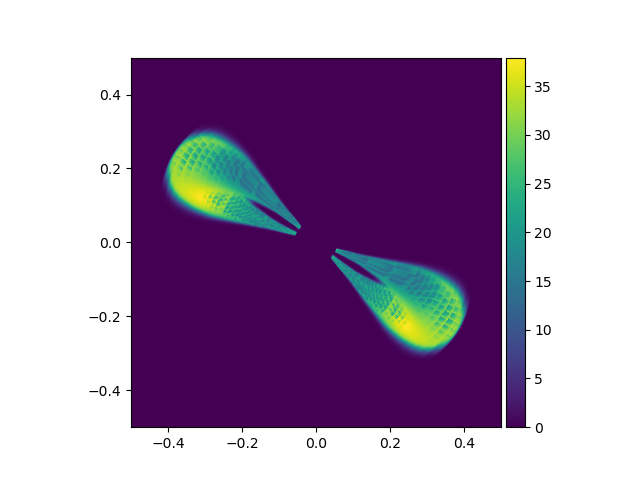

In [5]:
%matplotlib widget
visualization.slider(images)

In [ ]:
%matplotlib widget
fig, axes = plt.subplots(1,9, figsize=(20,4))
for ax, image in zip(axes, images):
    im = ax.imshow(image)
    ax.axis('off')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    
plt.tight_layout()

In [130]:
def temperature_profile_williams(z, r, T_mid1, T_atm1, q, M_star, m_mol, delta=2, r_scale=1):
    # Temperature at the mid-plane is a power law with 2 parameters
    # Atmospheric tempertature is a radial power law with 1 additional parameter
    # Typical values, T_mid1=200K, q=0.55, for Taurus protostars similar to those in the CO survey (Andrews et al. 2009)
    # r_scale is the scaling in AU (default = 1AU)
    T_mid = T_mid1 * (r/r_scale)**(-q)
    T_atm = T_atm1 * (r/r_scale)**(-q)

    # delta, z_q describe the steepness of the profile and the hight at which 
    # the disk transitions to the atmopheric value. H_p is the pressure scale hight
    # derived from the midplane tempertaure
    H_p = (r * au)**(3/2) * (kk*T_mid / (G*M_star*m_mol))**0.5
    z_q = 4*H_p/au
    
    # The temperature profile is a combination of T_mid, T_atm 
    temperature = jnp.where(jnp.abs(z)<z_q, T_mid + (T_atm - T_mid)*jnp.sin(jnp.pi*z/(2*z_q))**(2*delta), T_atm)
    return temperature

def temperature_profile_flaherty(z, r, T_mid1, T_atm1, q, M_star, m_mol, z_q0, r_scale):
    T_mid = T_mid1 * (r/r_scale)**(-q)
    T_atm = T_atm1 * (r/r_scale)**(-q)

    # The parameter Zq is the height above the midplane at which the gas temperature reaches its maximum value
    z_q = z_q0 * (r/r_scale)**1.3
    
    # The temperature profile is a combination of T_mid, T_atm 
    temperature = jnp.where(jnp.abs(z)<z_q, T_mid + (T_atm - T_mid)*jnp.cos(jnp.pi*z/(2*z_q))**2, T_atm)
    return temperature

def number_density_profile_williams(z, r, temperature, gamma, r_in, r_c, M_gas, M_star, m_mol):
    sigma_0 = (2-gamma) * (M_gas / (2*jnp.pi*(r_c*au)**2)) * jnp.exp(r_in / r_c)**(2-gamma)
    sigma = sigma_0 * (r[0] / r_c)**(-gamma) * jnp.exp(-(r[0]/r_c)**(2-gamma))
    dz = jnp.diff(z * au, axis=0)
    dlogrho = ( au**(-2) * G*M_star*z/(r**2 + z**2)**(3/2) ) * (m_mol / (kk * temperature))
    dlogrho = -0.5*(dlogrho[:-1] + dlogrho[1:]) - jnp.log(temperature[1:]/temperature[:-1])/dz
    logrho = jnp.cumsum(dlogrho*dz, axis=0)
    logrho = jnp.pad(logrho, pad_width=[(1,0), (0,0)])
    rho = jnp.exp(logrho)
    rho = sigma * rho / (1+jnp.sum(rho[1:]*dz, axis=0, keepdims=True))
    numberdens = rho/m_mol
    return numberdens

def number_density_profile_flaherty(z, r, temperature, gamma, r_c, M_gas, M_star, m_mol):
    sigma_0 = (2-gamma) * (M_gas / (2*jnp.pi*(r_c*au)**2))
    sigma = sigma_0 * (r[0] / r_c)**(-gamma) * jnp.exp(-(r[0]/r_c)**(2-gamma))
    dz = jnp.diff(z * au, axis=0)
    dlogrho = ( au**(-2) * G*M_star*z/(r**2 + z**2)**(3/2) ) * (m_mol / (kk * temperature))
    dlogrho = -0.5*(dlogrho[:-1] + dlogrho[1:]) - jnp.log(temperature[1:]/temperature[:-1])/dz
    logrho = jnp.cumsum(dlogrho*dz, axis=0)
    logrho = jnp.pad(logrho, pad_width=[(1,0), (0,0)])
    rho = jnp.exp(logrho)
    rho = sigma * rho / (1+jnp.sum(rho[1:]*dz, axis=0, keepdims=True))
    numberdens = rho/m_mol
    return numberdens
    

In [141]:
z_min, z_max = 0, 200
r_min, r_max = 9, 1000
resolution=500
r_in = 9
z, r = jnp.meshgrid(jnp.linspace(z_min, z_max, resolution), jnp.linspace(r_min, r_max, resolution), indexing='ij')
disk.r_scale = 150.0

temperature = temperature_profile_flaherty(z, r, disk.T_mid1, disk.T_atm1, disk.q, disk.M_star, disk.m_mol, disk.z_q0, disk.r_scale)

gamma= disk.gamma
r_c=disk.r_c
M_gas= disk.M_gas
M_star=disk.M_star
m_mol=disk.m_mol
sigma_0 = (2-gamma) * (M_gas / (2*jnp.pi*(r_c*au)**2))
sigma = sigma_0 * (r[0] / r_c)**(-gamma) * jnp.exp(-(r[0]/r_c)**(2-gamma))
dz = jnp.diff(z * au, axis=0)
dlogrho = ( au**(-2) * G*M_star*z/(r**2 + z**2)**(3/2) ) * (m_mol / (kk * temperature))
dlogrho = -0.5*(dlogrho[:-1] + dlogrho[1:]) - jnp.log(temperature[1:]/temperature[:-1])/dz
logrho = jnp.cumsum(dlogrho*dz, axis=0)
logrho = jnp.pad(logrho, pad_width=[(1,0), (0,0)])
rho = jnp.exp(logrho)
rho = sigma * rho / (1+jnp.sum(rho[1:]*dz, axis=0, keepdims=True))
numberdens = rho/m_mol

numberdens_h2 = numberdens

# Compute the column integrated density N(h2) (units of 1/cm^2)
dz = jnp.diff(z * au, axis=0)[0,0]
N_h2 = jnp.cumsum(numberdens_h2[::-1]*dz, axis=0)[::-1]

# CO chemestry, compute the relative abundance of co 
co_region = jnp.bitwise_and(temperature>disk.freezeout, jnp.bitwise_and(N_h2>=disk.N_h2_min, N_h2<=disk.N_h2_max))

abundance_co = jnp.where(co_region, disk.co_abundance, 0.0)
numberdens_co = abundance_co * numberdens_h2

In [143]:
# Make a spherical coordinate dataset with logarithmic spacing in r
phi, theta, r = np.meshgrid(np.linspace(0, 2*np.pi, 180), 
                            np.linspace(projection.theta_min, projection.theta_max, 120), 
                            au*np.logspace(np.log10(r_min), np.log10(r_max), 100), indexing='ij')
coords_sph = jnp.stack([phi, theta, r], axis=-1)

# Bounding box for interpolations (logarithmic r scale)
bbox_cyl = [(z_min*au, z_max*au), (r_min*au, r_max*au)]
bbox = [(phi.min(), phi.max()), (theta.min(), theta.max()), (np.log10(r.min()), np.log10(r.max()))]

# Polar coordinates with mirror and axial symmetry
r_polar = r * np.sin(theta)
z = np.abs(r * np.cos(theta))
coords_polar = np.stack((z, r), axis=-1)

# Interpolate the data on spherical coordinates
numberdens_co_sph = grid.interpolate_scalar(numberdens_co, coords_polar, bbox=bbox_cyl)
temperature_sph = grid.interpolate_scalar(temperature, coords_polar, bbox=bbox_cyl)
images = render_cube(projection, disk, freqs, numberdens_co_sph, temperature_sph, bbox)

line frequency: 345.7959899 Ghz
computing spectral cube for a total of 10 frequencies


/tmp/ipykernel_585034/3280702560.py:7: RuntimeWarning: divide by zero encountered in log10
  data = np.log10(numberdens_co)


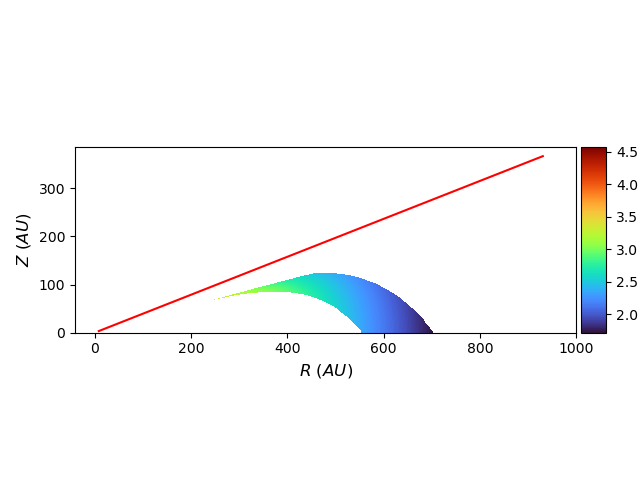

In [14]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
%matplotlib widget
fig, ax = plt.subplots()
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

data = np.log10(numberdens_co)
# data = jnp.bitwise_and(N_h2>=disk.N_h2_min, N_h2<=disk.N_h2_max)
# data = temperature>disk.freezeout

im = ax.imshow(data, origin='lower', cmap='turbo',  extent=[r_min, r_max, z_min, z_max])
cbar = fig.colorbar(im, cax=cax)
ax.set_xlabel(r'$R~(AU)$', fontsize=12)
ax.set_ylabel(r'$Z~(AU)$', fontsize=12)
plt.tight_layout()

#z, r = jnp.meshgrid(jnp.linspace(z_min, z_max, 500), jnp.linspace(r_min, r_max, 500), indexing='ij')
#levels = [20]
#cp = ax.contour(r, z, temperature, levels, colors='white')
#ax.clabel(cp, levels, inline=1, fontsize=12);

theta_max = np.deg2rad(68.5)
ax.plot(np.sin(theta_max)*np.linspace(r_min, r_max), np.cos(theta_max)*np.linspace(r_min, r_max), color='r')

/tmp/ipykernel_547913/2095978627.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(numberdens_co))


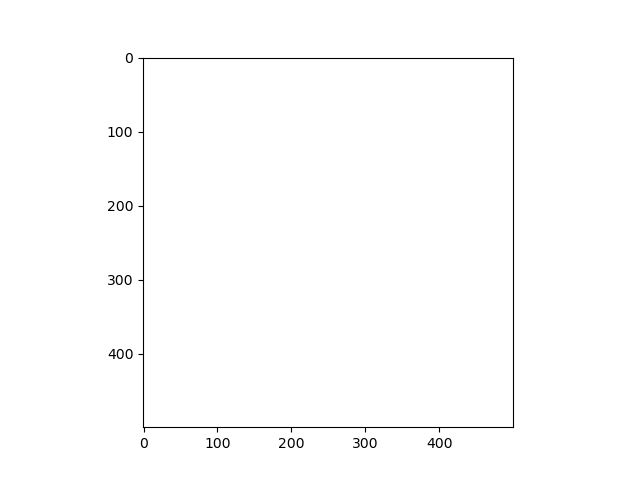

In [54]:
plt.figure()
plt.imshow(np.log10(numberdens_co))

interactive(children=(IntSlider(value=4, description='frame', max=9), Output()), _dom_classes=('widget-interac…

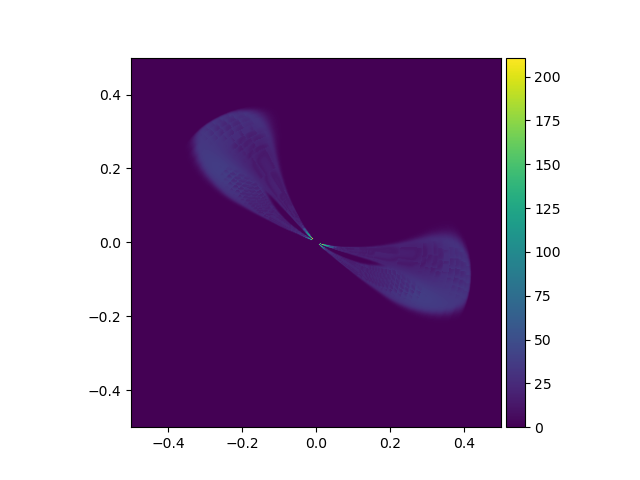

In [144]:
%matplotlib widget
visualization.slider(images)

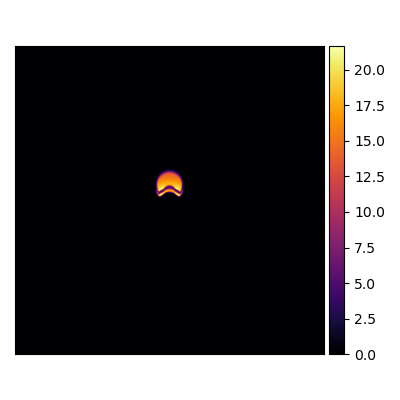

In [27]:
# Save outputs
out_dir = Path(data_dir).joinpath(params['name'])
out_dir.mkdir(parents=True, exist_ok=True)

# Dump parameters
yaml = YAML(typ='safe')
yaml.default_flow_style = False
with open(out_dir.joinpath('params.yaml'), 'w') as file:
    yaml.dump(params, file)

# Save ground truth fields and images  
np.save(out_dir.joinpath('numberdens_co_sph.npy'), numberdens_co_sph)
np.save(out_dir.joinpath('temperature_sph.npy'), temperature_sph)
np.savez(out_dir.joinpath('images.npz'), images=images, freq=)
np.savez(out_dir.joinpath('grid.npz'), phi=phi, theta=theta, r=r)

# Save a gif for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(1,1,figsize=(4,4))
visualization.animate_movies_synced([images], [axes], vmin=[0.0], cmaps='inferno', output=out_dir.joinpath('observed_cube.gif'))

Optimize parameters for a parametric model
--

In [3]:
# Load saved model
model_path = Path('../../data/parametric/model3')

yaml = YAML(typ='safe')
with open(model_path.joinpath('params.yaml'), 'r') as stream:
    params = yaml.load(stream)
disk = parametric_disk.Disk(**params['disk'])
projection = sensor.Projection(**params['projection'])

numberdens_co_sph = np.load(model_path.joinpath('numberdens_co_sph.npy'))
temperature_sph = np.load(model_path.joinpath('temperature_sph.npy'))
observed_cube = np.load(model_path.joinpath('images.npy')).reshape(projection.linelam, -1)
phi, theta, r = np.load(model_path.joinpath('grid.npz')).values()
bbox = [(phi.min(), phi.max()), (theta.min(), theta.max()), (np.log10(r.min()), np.log10(r.max()))]

In [4]:
pixel_area = (projection.fov/projection.npix)**2       # pixel area to convert radiances to Jy 
ray_coords, obs_dir = sensor.orthographic_disk_projection(projection.npix, projection.nray, projection.incl, projection.phi, projection.posang, 
                                                          projection.fov, projection.r_min, projection.r_max, projection.theta_min, projection.theta_max)
ray_coords_sph = grid.cartesian_to_spherical(ray_coords, logr=True)

# Interpolate dataset along the ray coordinates
gas_nd = grid.interpolate_scalar(numberdens_co_sph, ray_coords_sph, bbox)
gas_t  = grid.interpolate_scalar(temperature_sph, ray_coords_sph, bbox, cval=1e-10)
gas_v = parametric_disk.keplerian_velocity(ray_coords, disk.M_star)

# Einstein coefficient for spontaneous emission from level u to level d
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=disk.molecule_table)
_, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions)
n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions)
print('line frequency: {} Ghz'.format(projection.nu0/ghz))

# Compute line radiative transfer for a whole spectral cube
camera_freqs = sensor.compute_camera_freqs(projection.linelam, projection.width_kms, projection.nu0)

# Define a parallel mapping over several gpus
# compute_spectral_cube = line_rte.compute_spectral_cube
jax_map = jax.vmap(line_rte.compute_spectral_cube,
                   axis_name='freq', 
                   in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None))

jax_map = jax.jit(line_rte.compute_spectral_cube)

2024-05-08 09:20:24.357640: W external/xla/xla/service/gpu/nvptx_compiler.cc:698] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.4.131). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


line frequency: 345.7959899 Ghz


In [90]:
import jax.scipy.stats as stats
import functools
import emcee

class CubeSampler(object):
    def __init__(self, camera_freqs, gas_v, gas_t, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area, 
                 x_bounds, sigma):
        self.freqs = camera_freqs
        self.gas_v = gas_v
        self.gas_t = gas_t
        self.n_up = n_up
        self.n_dn = n_dn
        self.a_ud = a_ud
        self.b_ud = b_ud
        self.b_du = b_du
        self.ray_coords = ray_coords
        self.obs_dir = obs_dir
        self.nu0 = nu0
        self.pixel_area = pixel_area
        self.x_bounds = x_bounds
        self.sigma = sigma
    
    def logprior_fn(self, x):
        condition = jnp.logical_and(x>=self.x_bounds[0],x<=self.x_bounds[1])
        return jnp.where(condition, 0, -jnp.inf)

    @functools.partial(jax.jit, static_argnums=(0))
    def loglikelihood_fn(self, x, y):
        model = jnp.nan_to_num(
            jax_map(self.freqs, self.gas_v, self.gas_t, self.n_up, self.n_dn, self.a_ud, self.b_ud, self.b_du, self.ray_coords, self.obs_dir, self.nu0, self.pixel_area, x))
        logpdf = stats.norm.logpdf(y.ravel(), model.ravel(), self.sigma)
        return jnp.sum(logpdf)
        
    @functools.partial(jax.jit, static_argnums=(0))
    def logprobability_fn(self, x, y):
        return self.logprior_fn(x) + self.loglikelihood_fn(x, y)

cube_sampler = CubeSampler(
    camera_freqs[0], gas_v, gas_t, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, projection.nu0, pixel_area,
    x_bounds=[0.0, 1.0],
    sigma=1e-10
)

In [91]:
batch = 25
data_batch = observed_cube[batch, None]
cube_sampler.freqs = camera_freqs[batch]

ndim, nwalkers = 1, 10
p0 = np.random.uniform(*cube_sampler.x_bounds, (nwalkers, ndim))

sampler = emcee.EnsembleSampler(nwalkers, ndim, cube_sampler.logprobability_fn, args=[data_batch])
state = sampler.run_mcmc(p0, 1000, progress=True)

2024-05-08 10:14:16.700156: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1m4s:

  %slice.131 = f64[147456,99,3]{2,1,0} slice(f64[147456,100,3]{2,1,0} %constant.51), slice={[0:147456], [0:99], [0:3]}, metadata={op_name="jit(logprobability_fn)/jit(main)/jit(loglikelihood_fn)/jit(compute_spectral_cube)/jit(diff)/slice[start_indices=(0, 0, 0) limit_indices=(147456, 99, 3) strides=None]" source_file="/scratch/imaging/projects/protoplanetary/neural-lte/notebooks/../line_rte.py" source_line=102}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2024-05-08 10:14:25.030594: E external/xla/xla/serv

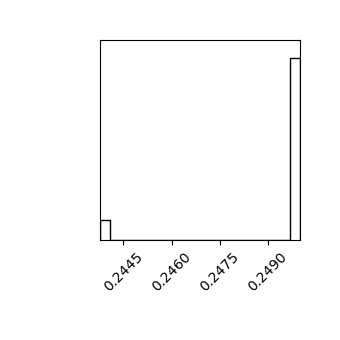

In [99]:
flat_samples = sampler.get_chain(discard=200, flat=True)

import corner
fig = corner.corner(flat_samples)

In [82]:
self = cube_sampler
x = 0.1
self.sigma = 1e-10
y = data_batch
model = jnp.nan_to_num(
    jax_map(self.freqs, self.gas_v, self.gas_t, self.n_up, self.n_dn, self.a_ud, self.b_ud, self.b_du, self.ray_coords, self.obs_dir, self.nu0, self.pixel_area, x))
jnp.sum(stats.norm.logpdf(y.ravel(), model.ravel(), self.sigma))

Array(-2.6315885e+25, dtype=float64)

In [83]:
self = cube_sampler
x = 0.25
self.sigma = 1e-10
y = data_batch
model = jnp.nan_to_num(
    jax_map(self.freqs, self.gas_v, self.gas_t, self.n_up, self.n_dn, self.a_ud, self.b_ud, self.b_du, self.ray_coords, self.obs_dir, self.nu0, self.pixel_area, x))
jnp.sum(stats.norm.logpdf(y, model, self.sigma))

Array(-2.6315885e+25, dtype=float64)

In [51]:
y = data_batch
jnp.sum(stats.norm.logpdf(y, model, self.sigma))

Array(-135503.00035223, dtype=float64)

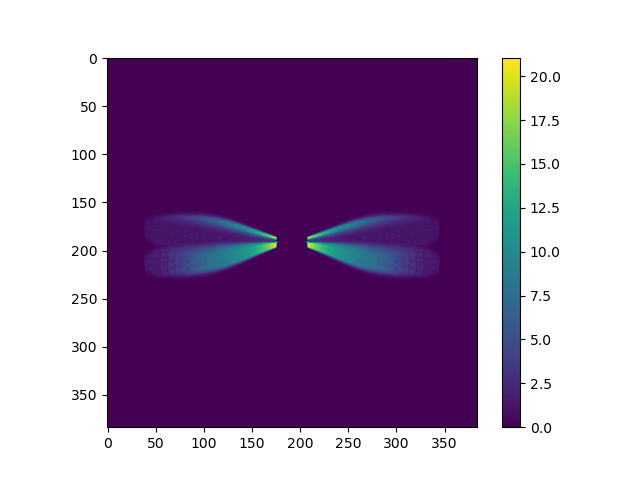

In [71]:
%matplotlib widget
plt.figure()
plt.imshow(model.reshape(384,384))
plt.colorbar()

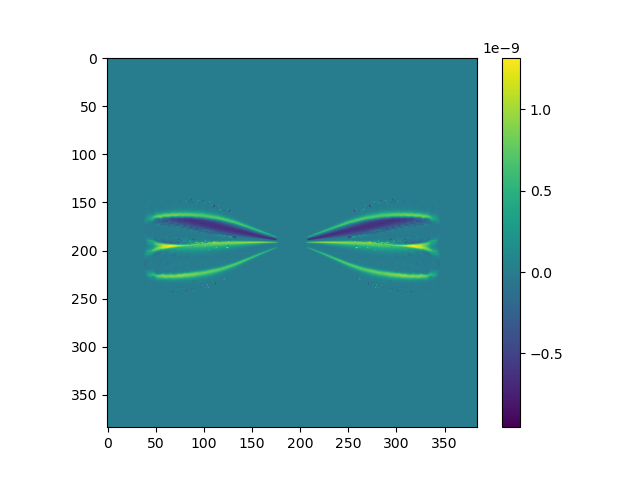

In [72]:
%matplotlib widget
plt.figure()
plt.imshow((data_batch-model).reshape(384,384))
plt.colorbar()

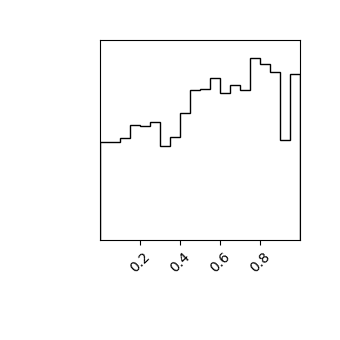

In [36]:
flat_samples = sampler.get_chain(discard=800, thin=1, flat=True)

import corner
fig = corner.corner(flat_samples)

In [76]:
import blackjax
import blackjax.sgmcmc.gradients as gradients

rng_key = jax.random.key(0) 

# Specify hyperparameters for SGLD
total_iter = 1000
thinning_factor = 10
num_samples = 100
batch_size = 4
lr = 1e-3
temperature = 50.0
init_position = 1.0

# Initialize and take one step using the vanilla SGLD algorithm
position = sgld.init(init_position)
sgld_sample_list = jnp.array([])

# Build the SGDL sampler
sampler = Sampler(camera_freqs[:batch_size], gas_v, gas_t, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, projection.nu0, pixel_area)
grad_fn = gradients.grad_estimator(sampler.logprior_fn, sampler.loglikelihood_fn, num_samples)
sgld = blackjax.sgld(grad_fn)
sgld_step = jax.jit(sgld.step)

In [77]:
%%timeit
sampler.loglikelihood_fn(alpha_turb, data_batch)

467 µs ± 111 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [99]:
sgld_step(sample_key, position, data_batch, lr, temperature)

Array(nan, dtype=float64)

In [52]:
thinning_factor = 1
total_iter = 1
for i in tqdm(range(total_iter)):
    rng_key, batch_key, sample_key = jax.random.split(rng_key, 3)
    batch = jax.random.permutation(batch_key, projection.linelam, independent=True)[:batch_size]
    data_batch = observed_cube[batch]
    sampler.freqs = camera_freqs[batch]
    position = sgld_step(sample_key, position, data_batch, lr, temperature)
    sgld_sample_list = jnp.append(sgld_sample_list, position)

  0%|          | 0/1 [00:00<?, ?it/s]

In [55]:
sgld_sample_list

Array([nan], dtype=float64)

In [5]:
import jax.scipy.stats as stats
import blackjax
from jax_tqdm import scan_tqdm
from jax import lax

alpha_turb0 = 1.0
num_samples = 100

def logdensity_fn(alpha_turb, observations, sigma):
    model = jnp.nan_to_num(jax_map(camera_freqs[0], gas_v, gas_t, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, projection.nu0, pixel_area, alpha_turb))
    logpdf = stats.norm.logpdf(observations, model, sigma)
    return jnp.sum(logpdf)

logdensity = lambda x: logdensity_fn(x, observed_cube[0], sigma=1.0)

inv_mass_matrix = np.array([1.0])
num_integration_steps = 60
step_size = 1e-3

hmc = blackjax.hmc(logdensity, step_size, inv_mass_matrix, num_integration_steps)
step = jax.jit(hmc.step)
state = hmc.init(alpha_turb0)
keys = jax.random.split(jax.random.key(0), num_samples)

ValueError: vmap was requested to map its argument along axis 0, which implies that its rank should be at least 1, but is only 0 (its shape is ())

In [6]:
states = [state]
for i, key in enumerate(tqdm(keys)):
    state, _ = step(key, state)
    states.append(state)

  0%|          | 0/100 [00:00<?, ?it/s]

2024-05-06 19:32:07.933643: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %slice.74 = f64[147456,99,3]{2,1,0} slice(f64[147456,100,3]{2,1,0} %constant.645), slice={[0:147456], [1:100], [0:3]}, metadata={op_name="jit(step_fn)/jit(main)/while/body/jvp(jit(diff))/slice[start_indices=(0, 1, 0) limit_indices=(147456, 100, 3) strides=None]" source_file="/scratch/imaging/projects/protoplanetary/neural-lte/notebooks/../line_rte.py" source_line=102}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2024-05-06 19:32:58.466539: E external/xla/xla/service/slow_operation_alarm.cc:133] The operat

In [6]:
hmc_kernel = 
num_samples = 100

for i in tqdm(
states = inference_loop(initial_key, hmc.step, initial_state, num_samples)

/srv/tmp/aviad/miniconda3/envs/jax/lib/python3.9/site-packages/jax/_src/interpreters/pxla.py:1858: UserWarning: The jitted function scan includes a pmap. Using jit-of-pmap can lead to inefficient data movement, as the outer jit does not preserve sharded data representations and instead collects input and output arrays onto a single device. Consider removing the outer jit unless you know what you're doing. See https://github.com/google/jax/issues/2926.
  warnings.warn(
2024-05-06 15:18:37.829755: W external/tsl/tsl/framework/bfc_allocator.cc:485] Allocator (GPU_3_bfc) ran out of memory trying to allocate 85.15GiB (rounded to 91427150848)requested by op 
2024-05-06 15:18:37.829908: W external/tsl/tsl/framework/bfc_allocator.cc:497] ***_________________________________________________________________________________________________
2024-05-06 15:18:37.830440: E external/xla/xla/pjrt/pjrt_stream_executor_client.cc:2732] Execution of replica 3 failed: RESOURCE_EXHAUSTED: Out of memory while

XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 91427150608 bytes.
BufferAssignment OOM Debugging.
BufferAssignment stats:
             parameter allocation:    1.04GiB
              constant allocation:       133B
        maybe_live_out allocation:     2.4KiB
     preallocated temp allocation:   85.15GiB
                 total allocation:   86.19GiB
Peak buffers:
	Buffer 1:
		Size: 5.49GiB
		Operator: op_name="jit(scan)/jit(main)/while/body/while/body/xla_pmap[backend=None axis_name=freq axis_size=5 global_axis_size=5 devices=None in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None) name=compute_spectral_cube donated_invars=(False, False, False, False, False, False, False, False, False, False, False, False, False) is_explicit_global_axis_size=False out_axes=(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)]" source_file="/tmp/ipykernel_356204/4005046484.

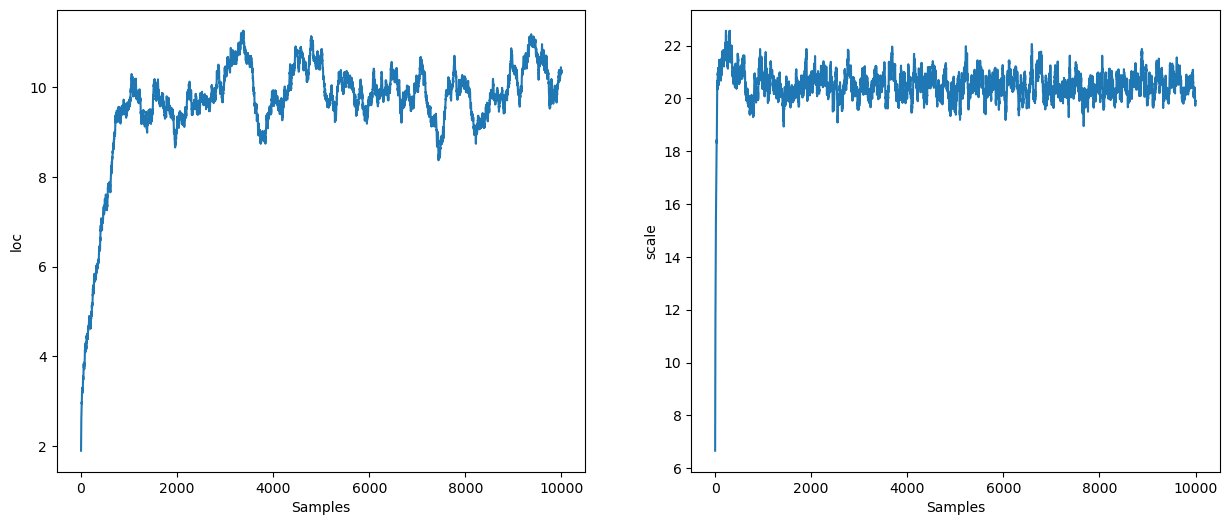

In [140]:
fig, (ax, ax1) = plt.subplots(ncols=2, figsize=(15, 6))
ax.plot(mcmc_samples["loc"])
ax.set_xlabel("Samples")
ax.set_ylabel("loc")

ax1.plot(mcmc_samples["scale"])
ax1.set_xlabel("Samples")
ax1.set_ylabel("scale");

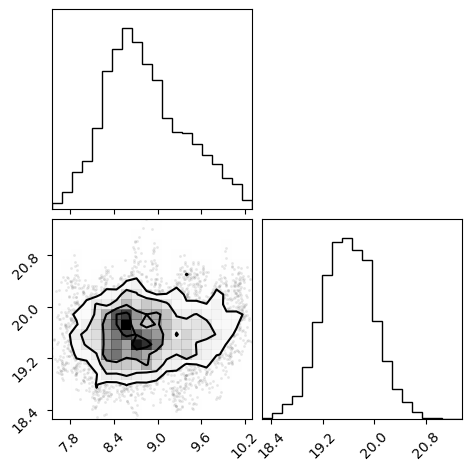

In [141]:
import corner
throw_away = 2000
figure = corner.corner(samples[throw_away:])

In [ ]:
images = pmap(shard(camera_freqs), gas_v, gas_t, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, projection.nu0, pixel_area, alpha_turb)

alpha_turb = 1.0
observations = shard(observed_cube)
model = jnp.nan_to_num(pmap(shard(camera_freqs), gas_v, gas_t, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, projection.nu0, pixel_area, alpha_turb))
logpdf = stats.norm.logpdf(observations, model, scale)

In [28]:
model_path = Path('../../data/parametric/model1')
images = np.load(model_path.joinpath('images.npy'))

model_path = Path('../../data/parametric/model3')
images1 = np.load(model_path.joinpath('images.npy'))

interactive(children=(IntSlider(value=24, description='frame', max=49), Output()), _dom_classes=('widget-inter…

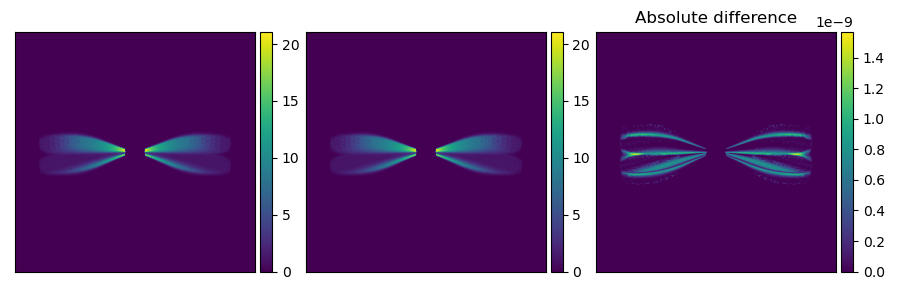

In [29]:
# Save a gif for the data cube for quick visualization
%matplotlib widget
visualization.slider_frame_comparison(images, images1)

In [33]:
# Load saved model
model_path = Path('../../data/parametric/model1')
with open(model_path.joinpath('params.yaml'), 'r') as stream:
    params = yaml.load(stream, Loader=yaml.Loader)
disk = parametric_disk.Disk(**params['disk'])
projection = sensor.Projection(**params['projection'])

numberdens_co_sph = np.load(model_path.joinpath('numberdens_co_sph.npy'))
temperature_sph = np.load(model_path.joinpath('temperature_sph.npy'))
images = np.load(model_path.joinpath('images.npy'))
phi, theta, r = np.load(model_path.joinpath('grid.npz')).values()
bbox = [(phi.min(), phi.max()), (theta.min(), theta.max()), (np.log10(r.min()), np.log10(r.max()))]

In [40]:
from flax import linen as nn

In [48]:
float(M_sun)

1.9884e+33

In [49]:
class ParametricDisk(nn.Module):
    @nn.compact
    def __call__(self):
        M_star = M_Sun * self.param('M_star', lambda key, values: jnp.array(values, dtype=jnp.float32), 1.0)
        return M_star



In [ ]:
ParametricDisk.

In [37]:
images = render_cube(numberdens_co_sph, temperature_sph, **params['sensor'], M_star=params['disk']['M_star'], bbox=bbox)

TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float32[].
The error occurred while tracing the function render_cube at /tmp/ipykernel_3544711/3142189789.py:62 for jit. This concrete value was not available in Python because it depends on the value of the argument bbox[0][0].
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.TracerArrayConversionError